In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score        

In [12]:
df = pd.read_csv(r'C:\Users\User\Downloads\advanced_business_dataset-1.csv')

In [13]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [14]:
df = df.drop_duplicates()

print("\nAfter Cleaning Shape:", df.shape)


df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Profit_Margin'] = df['Profit'] / df['Revenue']

print("\nStatistical Summary:\n", df.describe())

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Columns:", numerical_cols)


After Cleaning Shape: (800, 14)

Statistical Summary:
        Order_ID                 Date  Units_Sold   Unit_Price  Discount_%  \
count  800.0000                  800  800.000000   800.000000  800.000000   
mean   400.5000  2024-06-28 23:45:36    8.145000   771.846250    9.481250   
min      1.0000  2024-01-01 00:00:00    1.000000    51.000000    0.000000   
25%    200.7500  2024-04-01 00:00:00    4.000000   447.500000    5.000000   
50%    400.5000  2024-07-02 00:00:00    8.000000   764.000000   10.000000   
75%    600.2500  2024-09-25 00:00:00   12.000000  1129.000000   15.000000   
max    800.0000  2024-12-31 00:00:00   15.000000  1496.000000   20.000000   
std    231.0844                  NaN    4.378406   404.150934    7.098425   

            Revenue          Cost       Profit       Month    Year  \
count    800.000000    800.000000   800.000000  800.000000   800.0   
mean    5695.194875   3688.087425  2007.107450    6.440000  2024.0   
min      112.200000     79.530000    28.

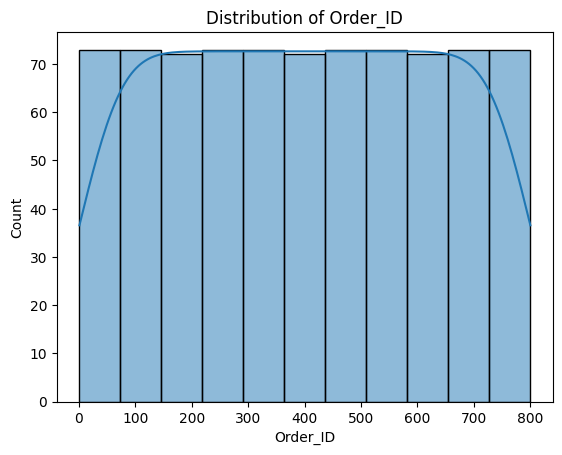

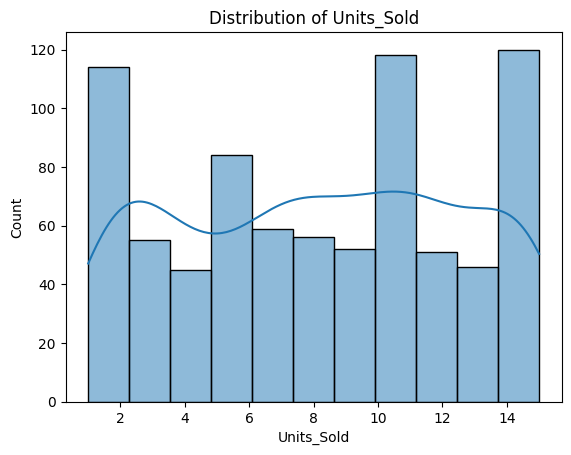

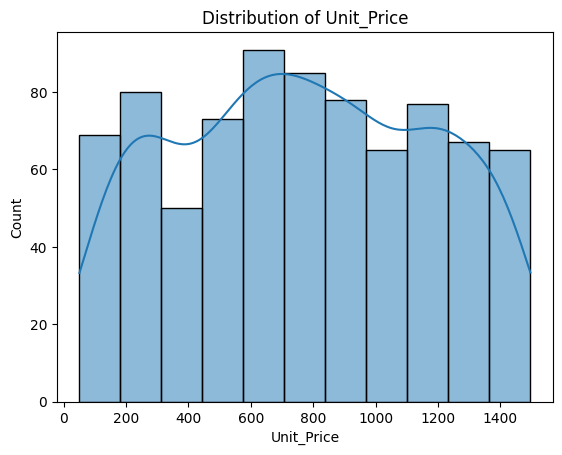

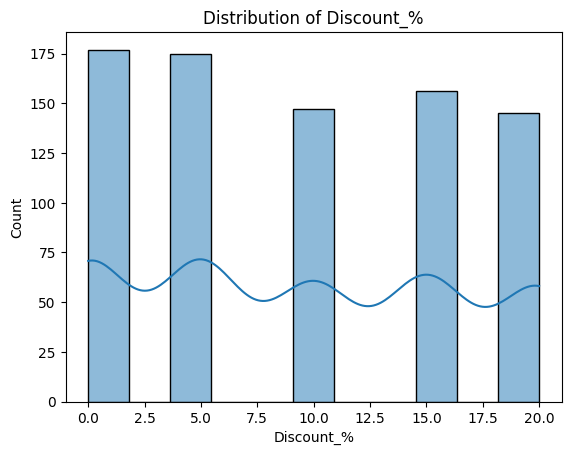

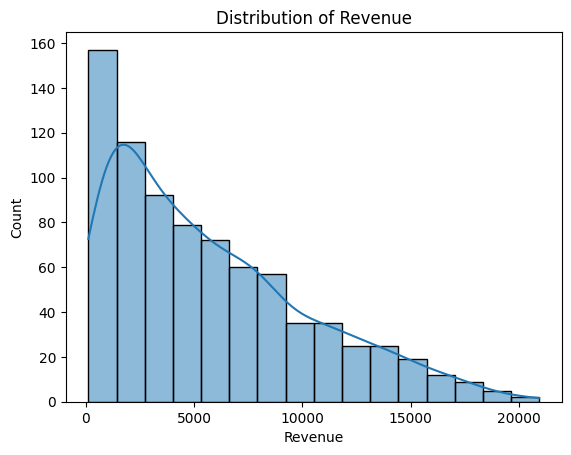

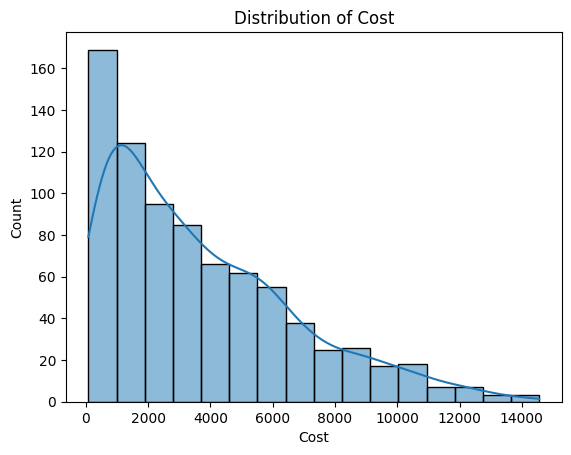

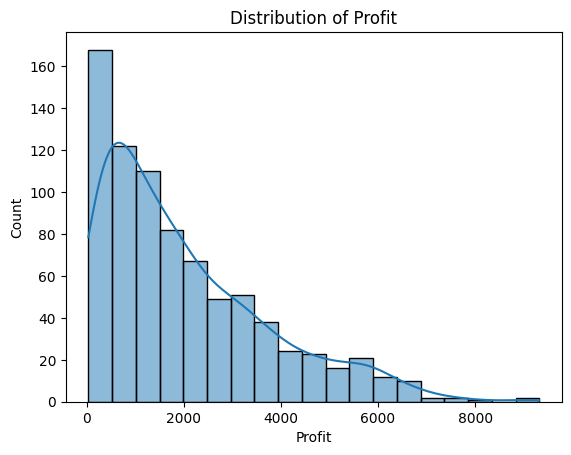

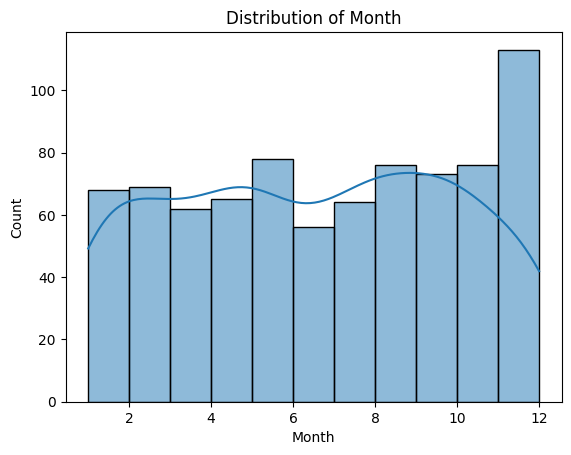

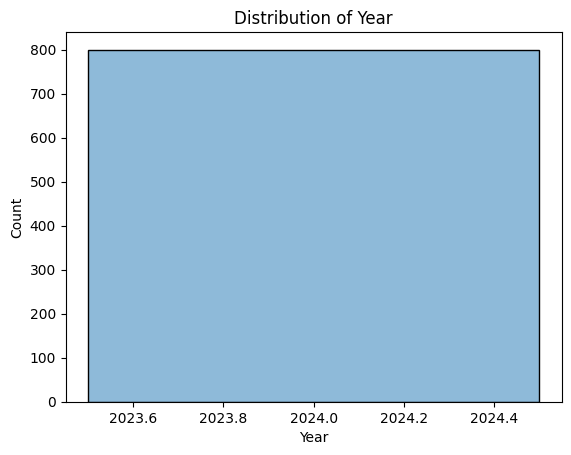

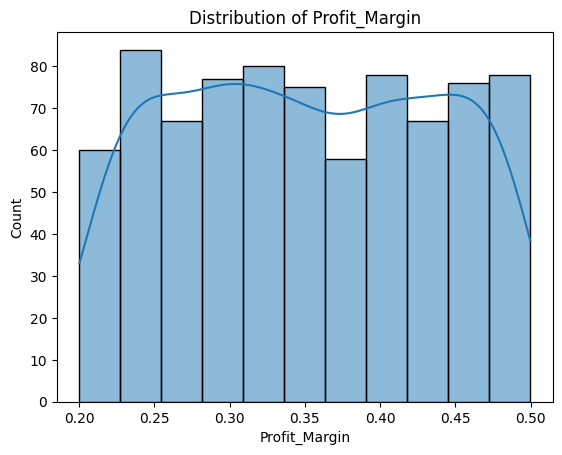

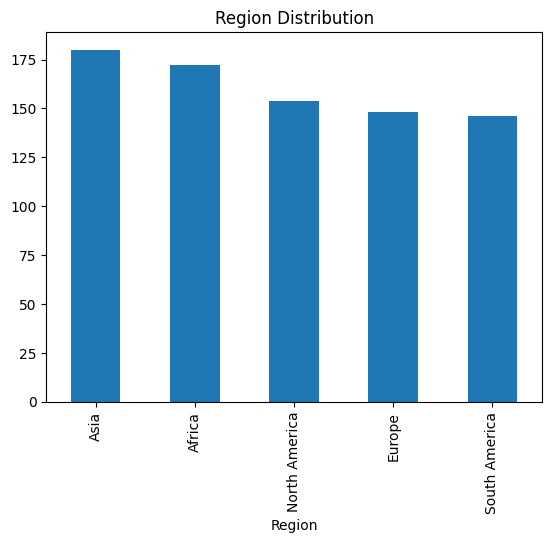

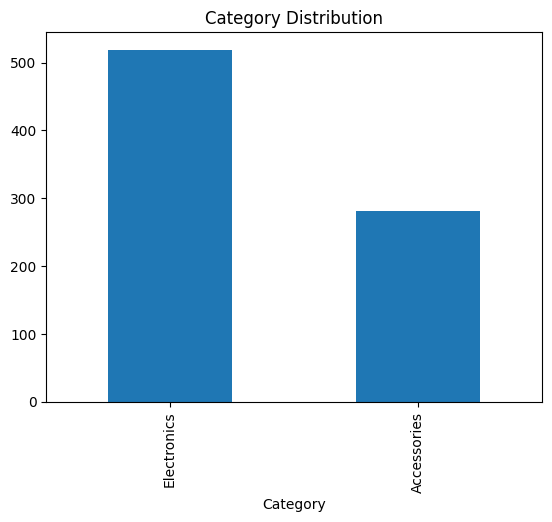

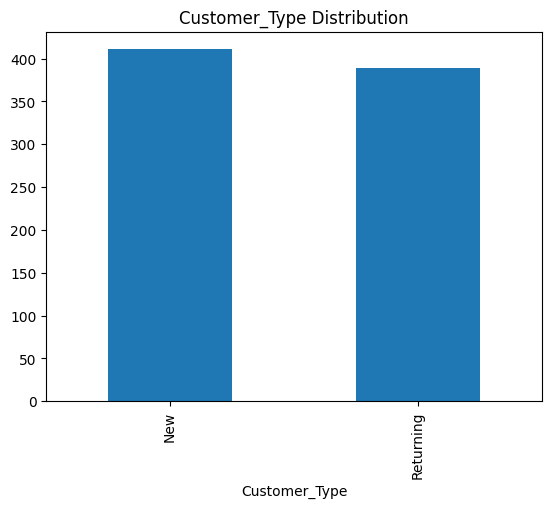

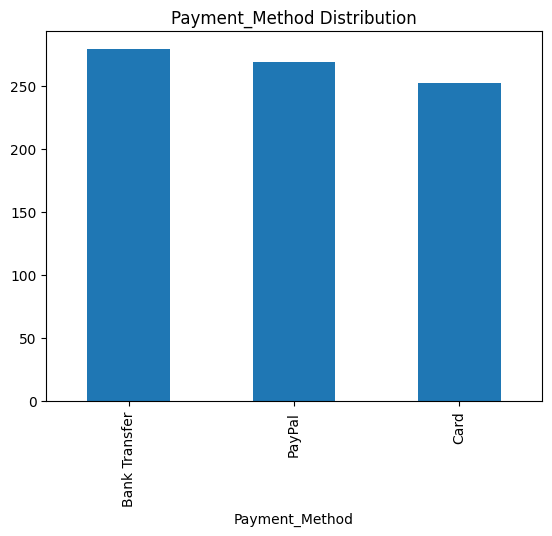

In [15]:
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

categorical_cols = ['Region', 'Category', 'Customer_Type', 'Payment_Method']

for col in categorical_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.show()


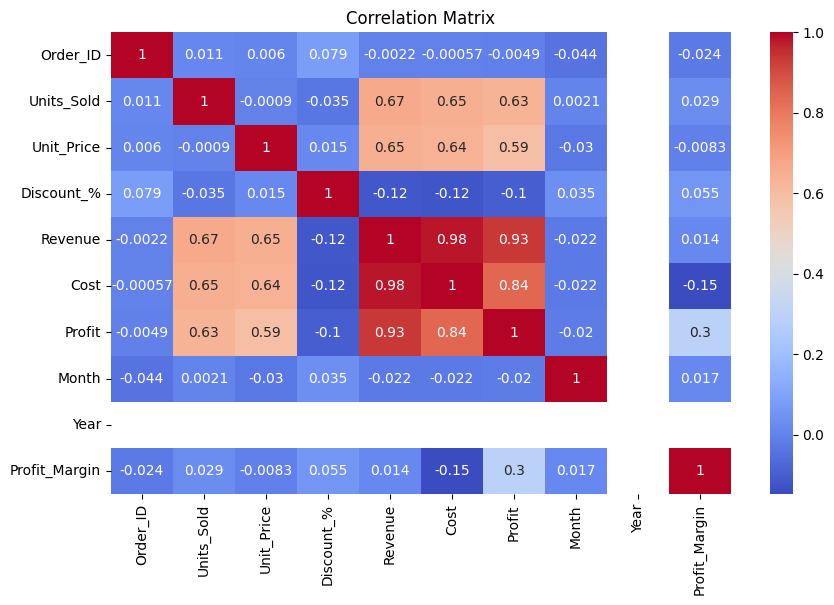

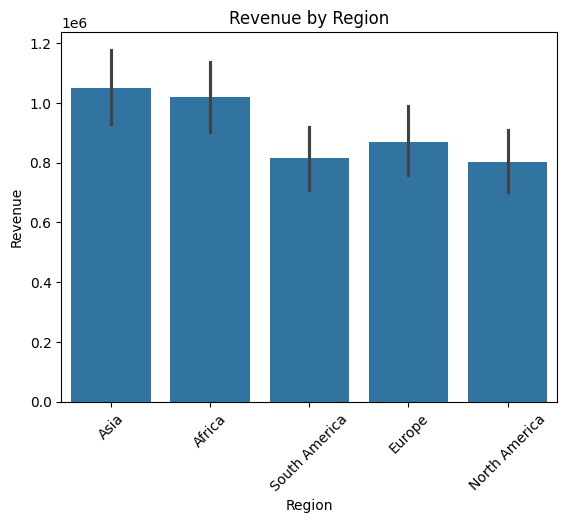

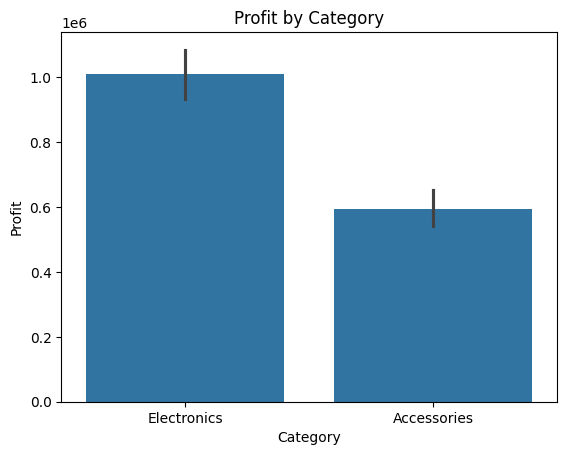

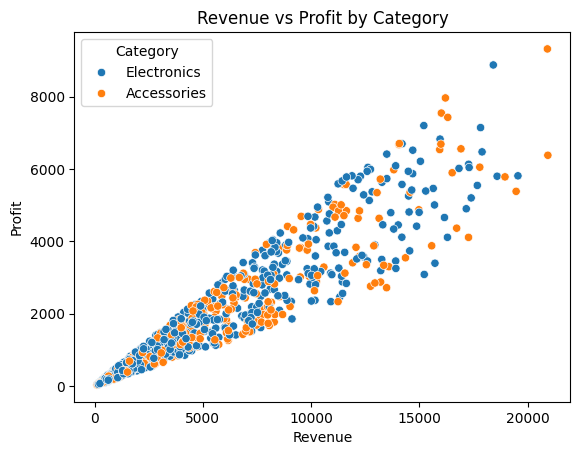

In [16]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Revenue by Region
plt.figure()
sns.barplot(x='Region', y='Revenue', data=df, estimator=np.sum)
plt.title("Revenue by Region")
plt.xticks(rotation=45)
plt.show()

# Profit by Category
plt.figure()
sns.barplot(x='Category', y='Profit', data=df, estimator=np.sum)
plt.title("Profit by Category")
plt.show()


plt.figure()
sns.scatterplot(x='Revenue', y='Profit', hue='Category', data=df)
plt.title("Revenue vs Profit by Category")
plt.show()

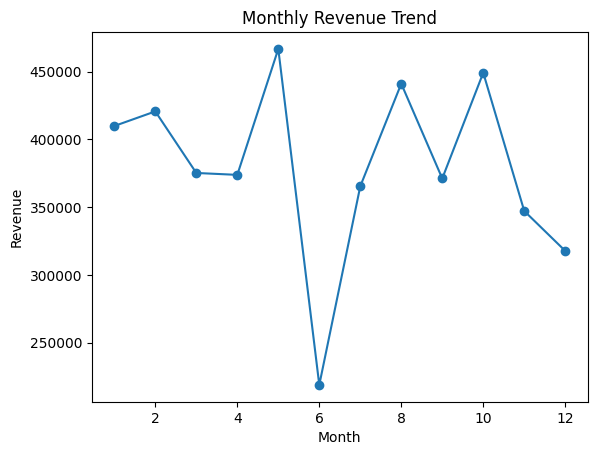

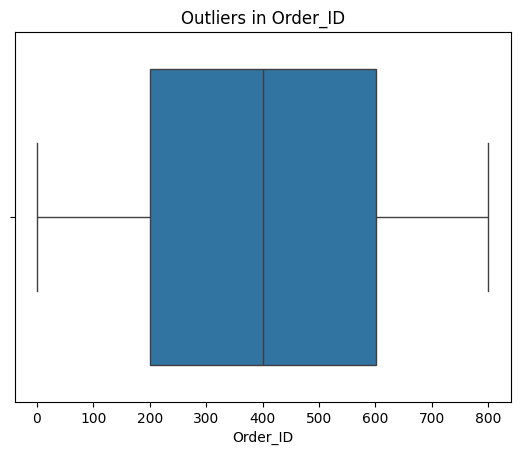

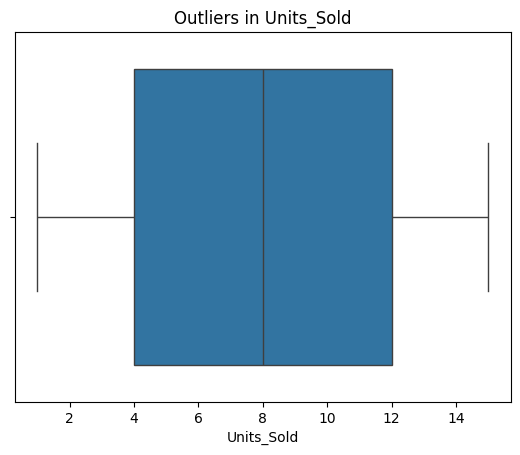

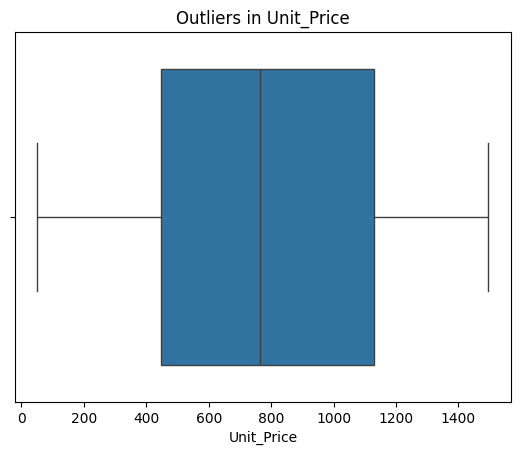

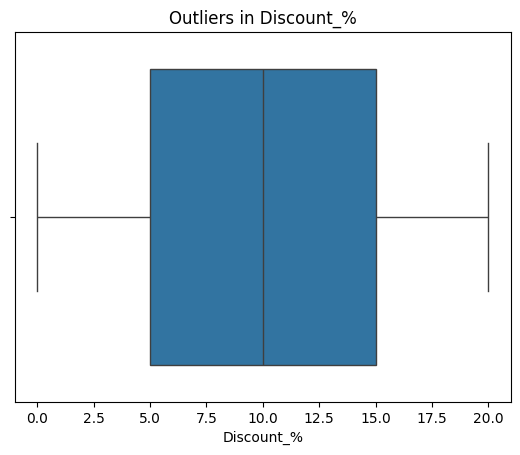

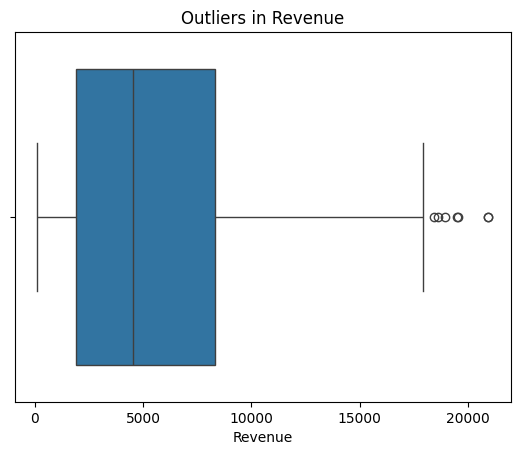

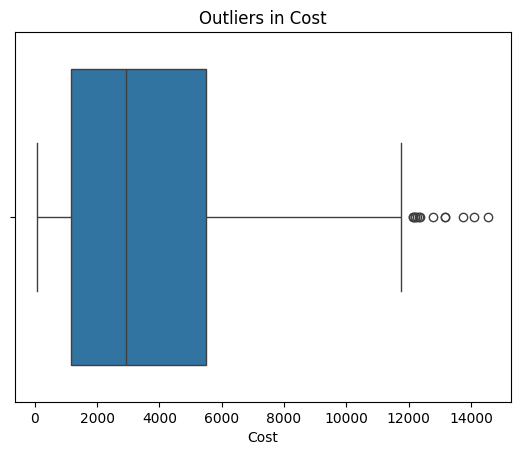

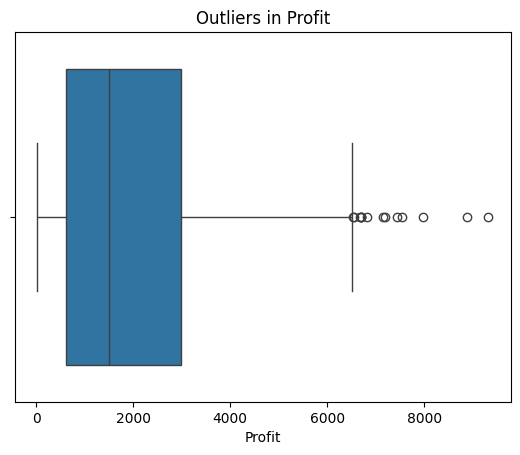

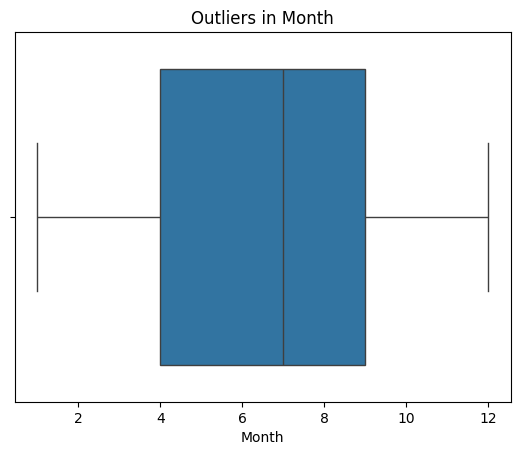

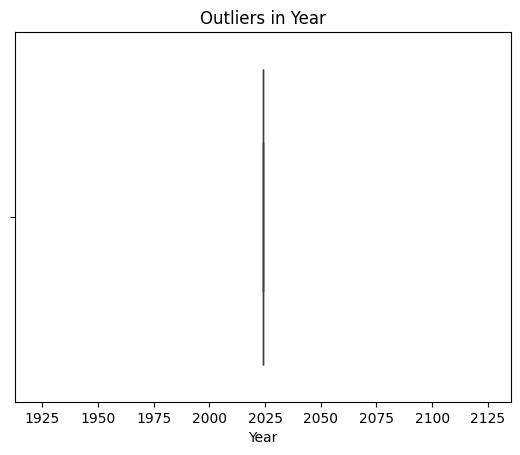

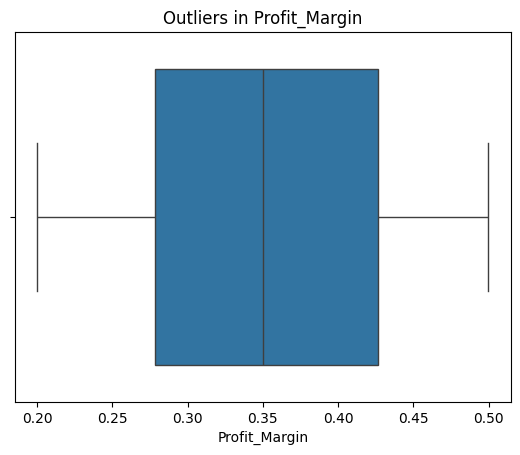


Region Summary:
                   Revenue     Profit
Region                              
Africa         1018683.70  350556.88
Asia           1050173.30  379864.75
Europe          870663.45  298603.16
North America   801821.15  287388.01
South America   814814.30  289273.16

Category Summary:
                Revenue      Profit
Category                          
Accessories  1719445.5   594276.89
Electronics  2836710.4  1011409.07


In [17]:

#TIME SERIES ANALYSIS

monthly_sales = df.groupby('Month')['Revenue'].sum()

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

# OUTLIER DETECTION
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()

# GROUPED INSIGHTS

region_summary = df.groupby('Region')[['Revenue', 'Profit']].sum()
category_summary = df.groupby('Category')[['Revenue', 'Profit']].sum()

print("\nRegion Summary:\n", region_summary)
print("\nCategory Summary:\n", category_summary)


In [18]:
# SAVE CLEANED DATA & REPORT
df.to_csv("cleaned_dataset.csv", index=False)

region_summary.to_csv("region_summary.csv")
category_summary.to_csv("category_summary.csv")

print("\nEDA Pipeline Completed Successfully!")


EDA Pipeline Completed Successfully!
